# Data Exploration
Dataset: Allociné (HuggingFace)  
Goal: Understand the data before fine-tuning CamemBERT

In [5]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the dataset

In [6]:
dataset = load_dataset('allocine')
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 160000
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
})


In [7]:
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(f'Train size: {len(train_df)}')
print(f'Test size:  {len(test_df)}')
train_df.head()

Train size: 160000
Test size:  20000


,review,label
0,Si vous cherchez du cinéma abrutissant à tous ...,0
1,"Trash, re-trash et re-re-trash...! Une horreur...",0
2,"Et si, dans les 5 premières minutes du film, l...",0
3,Mon dieu ! Quelle métaphore filée ! Je suis ab...,0
4,"Premier film de la saga Kozure Okami, ""Le Sabr...",1


## 2. Class balance

label_name
Positive    80587
Negative    79413
Name: count, dtype: int64


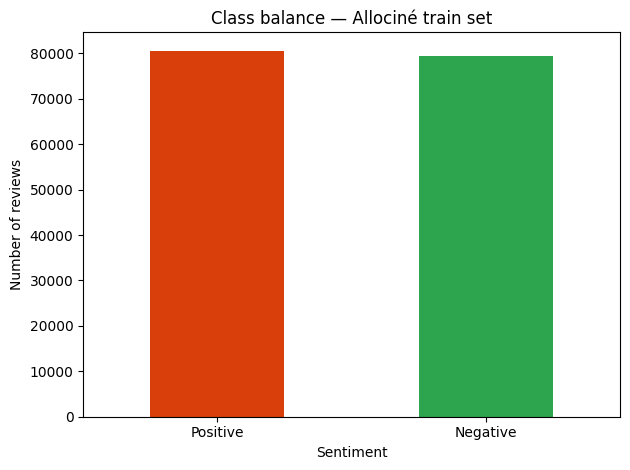

In [8]:
label_map = {0: 'Negative', 1: 'Positive'}
train_df['label_name'] = train_df['label'].map(label_map)

counts = train_df['label_name'].value_counts()
print(counts)

counts.plot(kind='bar', color=['#d93f0b', '#2da44e'], edgecolor='none')
plt.title('Class balance — Allociné train set')
plt.xlabel('Sentiment')
plt.ylabel('Number of reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/figures/class_balance.png', dpi=150)
plt.show()

Positive: 80 587 (50.4%) and Negative: 79 413 (49.6%). The dataset is almost perfectly balanced, no oversampling or class weighting needed.

## 3. Text length distribution

count    160000.000000
mean         91.301431
std          75.357588
min           1.000000
25%          34.000000
50%          66.000000
75%         130.000000
max         384.000000
Name: text_length, dtype: float64


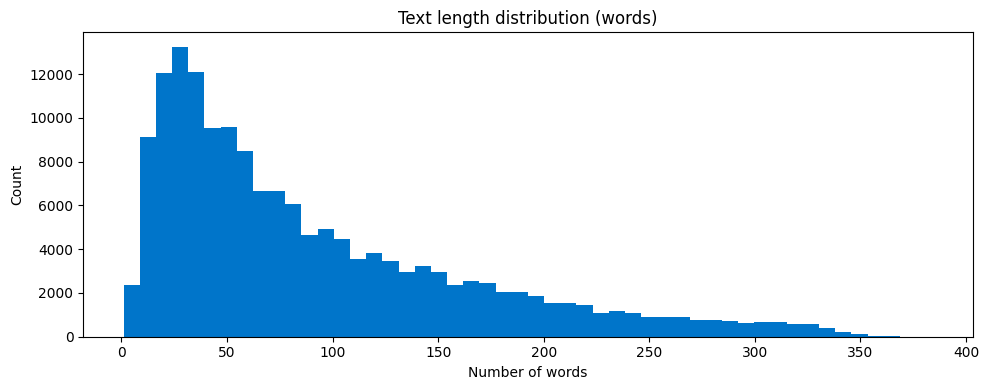

In [9]:
train_df['text_length'] = train_df['review'].apply(lambda x: len(x.split()))

print(train_df['text_length'].describe())

plt.figure(figsize=(10, 4))
plt.hist(train_df['text_length'], bins=50, color='#0075ca', edgecolor='none')
plt.title('Text length distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/figures/text_length.png', dpi=150)
plt.show()

- Mean: 91 words, Median: 66 words, Max: 384 words
- The distribution is right-skewed, most reviews are short (20-100 words)
- Since CamemBERT supports up to 512 tokens, truncation will rarely be needed

## 4. Sample reviews

In [10]:
print('=== POSITIVE REVIEW ===')
print(train_df[train_df['label'] == 1]['review'].iloc[0])

print('\n=== NEGATIVE REVIEW ===')
print(train_df[train_df['label'] == 0]['review'].iloc[0])

=== POSITIVE REVIEW ===
Premier film de la saga Kozure Okami, "Le Sabre de la vengeance" est un très bon film qui mêle drame et action, et qui, en 40 ans, n'a pas pris une ride.

=== NEGATIVE REVIEW ===
Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via sa filière EuropaCorp ont de quoi faire naître la moquerie.Paris y est encore une fois montrée comme une capitale exotique,mais attention si l'on se dirige vers la banlieue,on y trouve tout plein d'intégristes musulmans prêts à faire sauter le caisson d'une ambassadrice américaine.Nauséeux.Alors on se dit qu'on va au moins pouvoir apprécier la déconnade d'un classique buddy-movie avec le jeune agent aux dents longues obligé de faire équipe avec un vieux lou complètement timbré.Mais d'un côté,on a un Jonathan Rhys-meyers fayot au possible,et de l'autre un John Travolta en total délire narci

- The positive review is short and enthusiastic
- The negative review is long, detailed and critical
- Both are written in natural French, perfect for CamemBERT which was trained on French text

## 5. Key observations

- Dataset size: 160 000 train reviews, 20 000 test reviews
- Class balance: Almost perfectly balanced, positive: 80 587 (50.4%)/ negative: 79 413 (49.6%)
- Average text length: 91 words per review
- Max text length: 384 words, important for CamemBERT tokenization (max 512 tokens)
- Distribution: Right-skewed, most reviews are between 20-100 words, few very long reviews
- Conclusion: The dataset is clean and well-balanced, ready for fine-tuning without preprocessing issues